# Dataset Inspection y OBB Validation

## Importación de librerias y configuración
Instalamos y cargamos las herramientas necesarias. Usaremos Pathlib para una gestión de rutas independiente del sistema operativo.

In [3]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import os

# Configuración de rutas
BASE_DIR = Path("data")
IMG_DIR = BASE_DIR / "processed" / "train"
CSV_PATH = BASE_DIR / "processed" / "val" / "data_300.csv"

# Parámetros de visualización
PLOTS_DIR = Path("reports/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    1: "auto", 2: "combi", 3: "microbus", 4: "minibus", 
    5: "omnibus", 6: "articulado", 7: "camion", 8: "mototaxi", 9: "motocicleta"
}

## Carga y validación de integridad
El primer paso es asegurar que cada registro en el CSV tenga su correspondiente archivo de imagen.

In [4]:
df = pd.read_csv(CSV_PATH)

# Verificar archivos físicos vs registros en CSV
existing_images = {f.stem for f in IMG_DIR.glob("*.jpg")} # .stem obtiene el nombre sin extensión
csv_ids = set(df['Id'].astype(str))

missing_in_disk = csv_ids - existing_images
missing_in_csv = existing_images - csv_ids

print(f"Total registros en CSV: {len(csv_ids)}")
print(f"Total imágenes en disco: {len(existing_images)}")
print(f"Imágenes faltantes en disco: {len(missing_in_disk)}")
print(f"IDs en disco no registrados en CSV: {len(missing_in_csv)}")

# Filtrar el dataframe para quedarnos solo con lo que existe (para la muestra de 300)
df = df[df['Id'].astype(str).isin(existing_images)].reset_index(drop=True)

Total registros en CSV: 300
Total imágenes en disco: 300
Imágenes faltantes en disco: 0
IDs en disco no registrados en CSV: 0


# Parsing de la columna Target (OBB)
La columna Target contiene múltiples objetos por imagen. Necesitamos "desenvolver" esta información para analizarla. Asumimos el formato: class_id cx cy w h angle.

In [6]:
def parse_target(target_str):
    if pd.isna(target_str) or target_str.lower() == "none":
        return []
    
    obj_strings = target_str.split(';')
    parsed_objs = []
    
    for obj_s in obj_strings:
        data = obj_s.strip().split(' ')
        if len(data) == 6:
            parsed_objs.append({
                'class_id': int(data[0]),
                'cx': float(data[1]),
                'cy': float(data[2]),
                'w': float(data[3]),
                'h': float(data[4]),
                'angle': float(data[5])
            })
    return parsed_objs

# Carga eficiente
df = pd.read_csv(CSV_PATH)
df['objects'] = df['Target'].apply(parse_target)
df['count'] = df['objects'].apply(len)

print(f"Muestra cargada: {len(df)} filas")
print(f"Total objetos detectados en muestra: {df['count'].sum()}")

Muestra cargada: 300 filas
Total objetos detectados en muestra: 3240


# Análisis de Consistencia y Calidad
Detectamos si hay etiquetas fuera de los límites de la imagen (asumiendo resolución estándar de cámaras de tráfico, ej. 1920x1080).

In [7]:
# Estadísticas descriptivas de los objetos
all_objs_list = [obj for sublist in df['objects'] for obj in sublist]
df_stats = pd.DataFrame(all_objs_list)

if not df_stats.empty:
    print("Distribución de Clases en la muestra:")
    print(df_stats['class_id'].map(CLASS_NAMES).value_counts())
    
    # Verificación de ángulos (Outliers)
    print(f"\nRango de ángulos detectado: {df_stats['angle'].min()}° a {df_stats['angle'].max()}°")

Distribución de Clases en la muestra:
class_id
auto           2610
motocicleta     247
camion          163
minibus          94
combi            57
mototaxi         33
microbus         19
omnibus          14
articulado        3
Name: count, dtype: int64

Rango de ángulos detectado: 0.0° a 359.9°


# Visualización de Cajas Orientadas (OBB)
Utilizamos cv2.boxPoints para convertir (center, size, angle) en los 4 vértices para dibujo.

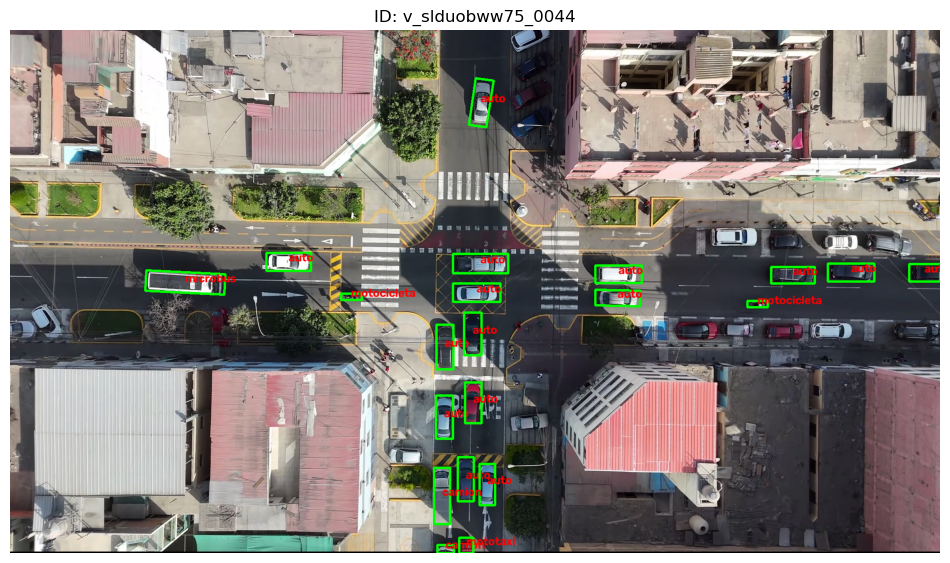

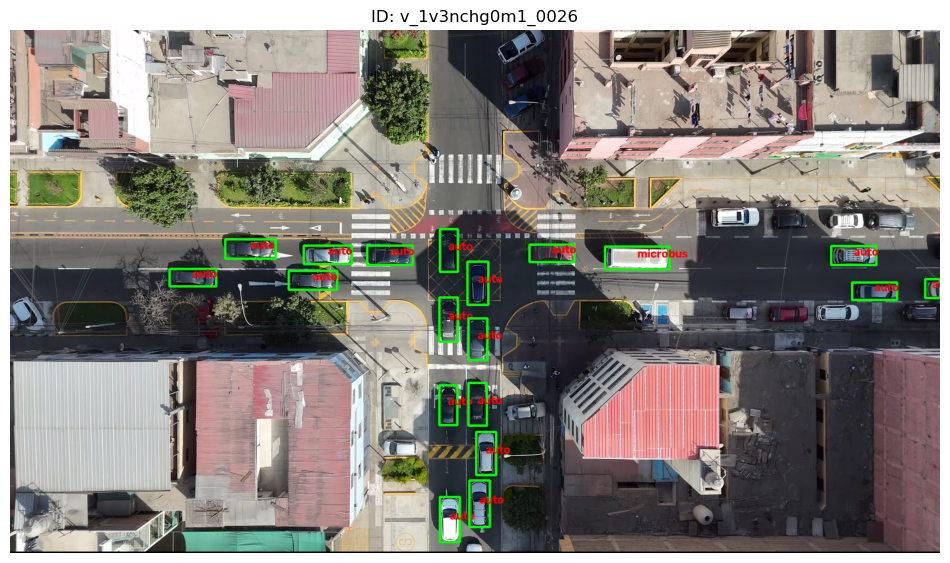

In [13]:
def get_obb_vertices(cx, cy, w, h, angle):
    """Convierte parámetros OBB a 4 vértices."""
    # En OpenCV, el ángulo suele ser antihorario. 
    # Validamos visualmente si el dataset sigue esta convención.
    rect = ((cx, cy), (w, h), angle)
    box = cv2.boxPoints(rect)
    return np.intp(box)

def visualize_sample(df, n=2):
    sample_df = df[df['count'] > 0].sample(n)
    
    for _, row in sample_df.iterrows():
        img_path = IMG_DIR / f"{row['Id']}.jpg"
        if not img_path.exists(): continue
        
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        for obj in row['objects']:
            box = get_obb_vertices(obj['cx'], obj['cy'], obj['w'], obj['h'], obj['angle'])
            cv2.drawContours(img, [box], 0, (0, 255, 0), 3)
            cv2.putText(img, CLASS_NAMES[obj['class_id']], (int(obj['cx']), int(obj['cy'])),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
            
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(f"ID: {row['Id']}")
        plt.axis('off')
        plt.show()

visualize_sample(df)

# Aplicación de una CNN